# 🌾 Crop Yield Prediction — End-to-End Machine Learning Pipeline

> **Dataset:** `crop_yield.csv`  |  **Target:** `Yield`  |  **Task:** Regression  

---
### Table of Contents
1. Import Libraries  
2. Load & Inspect Data  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering & Preprocessing  
5. Train-Test Split  
6. Feature Scaling  
7. Model Training  
8. Model Comparison & Visualisation  
9. Save Artefacts  

---
## 1. Import Libraries

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib

---
## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('crop_yield.csv')
df.head(10)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636
6,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
7,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
8,Linseed,1997,Rabi,Assam,10098.0,5158,2051.4,961026.66,3130.38,0.461364
9,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652


In [3]:
print('--- DATA TYPES ---')
print(df.dtypes)
print('\n--- MISSING VALUES ---')
print(df.isnull().sum())

--- DATA TYPES ---
Crop                   str
Crop_Year            int64
Season                 str
State                  str
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

--- MISSING VALUES ---
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [4]:
print('--- STATISTICAL SUMMARY ---')
df.describe().T.style.background_gradient(cmap='Blues')

--- STATISTICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Crop_Year,19689.000000,2009.127584,6.498099,1997.000000,2004.000000,2010.000000,2015.000000,2020.000000
Area,19689.000000,179926.570308,732828.675888,0.500000,1390.000000,9317.000000,75112.000000,50808100.000000
Production,19689.000000,16435941.273097,263056839.812568,0.000000,1393.000000,13804.000000,122718.000000,6326000000.000000
Annual_Rainfall,19689.000000,1437.755177,816.909589,301.300000,940.700000,1247.600000,1643.700000,6552.700000
Fertilizer,19689.000000,24103312.448806,94946004.482527,54.170000,188014.620000,1234957.440000,10003847.200000,4835406877.000000
Pesticide,19689.000000,48848.353392,213287.354860,0.090000,356.700000,2421.900000,20041.700000,15750511.000000
Yield,19689.000000,79.954009,878.306193,0.000000,0.600000,1.030000,2.388889,21105.000000


In [5]:
print(f'Unique Crops : {df["Crop"].nunique()}')
print(f'Unique States : {df["State"].nunique()}')
print(f'Seasons : {df["Season"].str.strip().unique().tolist()}')
print(f'Year Range : {df["Crop_Year"].min()} to {df["Crop_Year"].max()}')

Unique Crops : 55
Unique States : 30
Seasons : ['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter']
Year Range : 1997 to 2020


---
## 3. Exploratory Data Analysis (EDA)

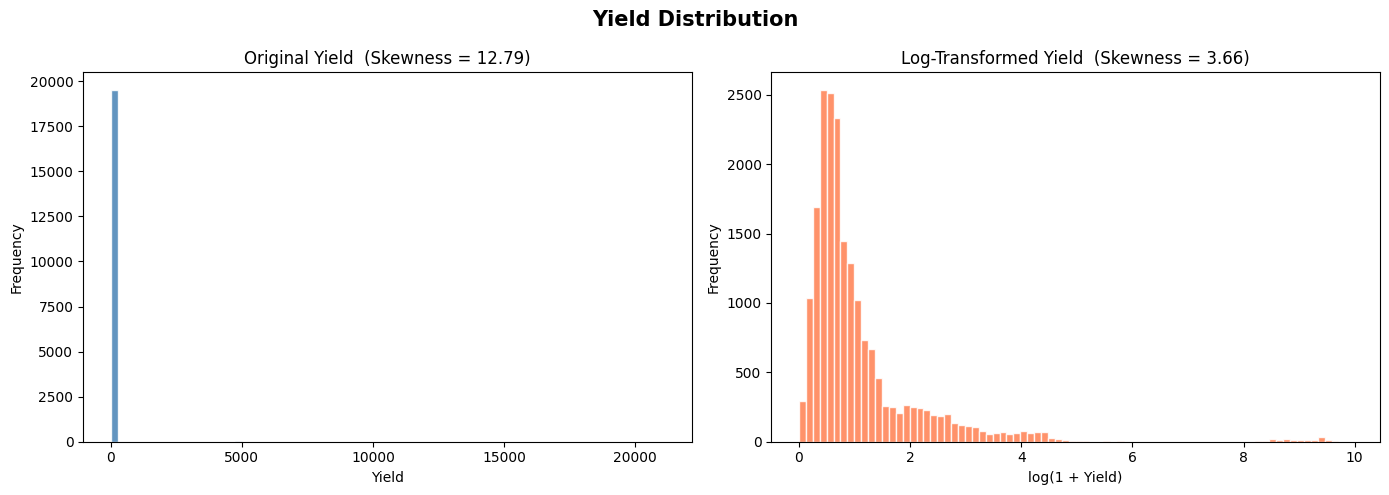

In [6]:
# 3.1 — Target Distribution (Original vs Log-Transformed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Yield Distribution', fontsize=15, fontweight='bold')

axes[0].hist(df['Yield'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Original Yield  (Skewness = %.2f)' % df['Yield'].skew())
axes[0].set_xlabel('Yield'); axes[0].set_ylabel('Frequency')

log_yield = np.log1p(df['Yield'])
axes[1].hist(log_yield, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Yield  (Skewness = %.2f)' % log_yield.skew())
axes[1].set_xlabel('log(1 + Yield)'); axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

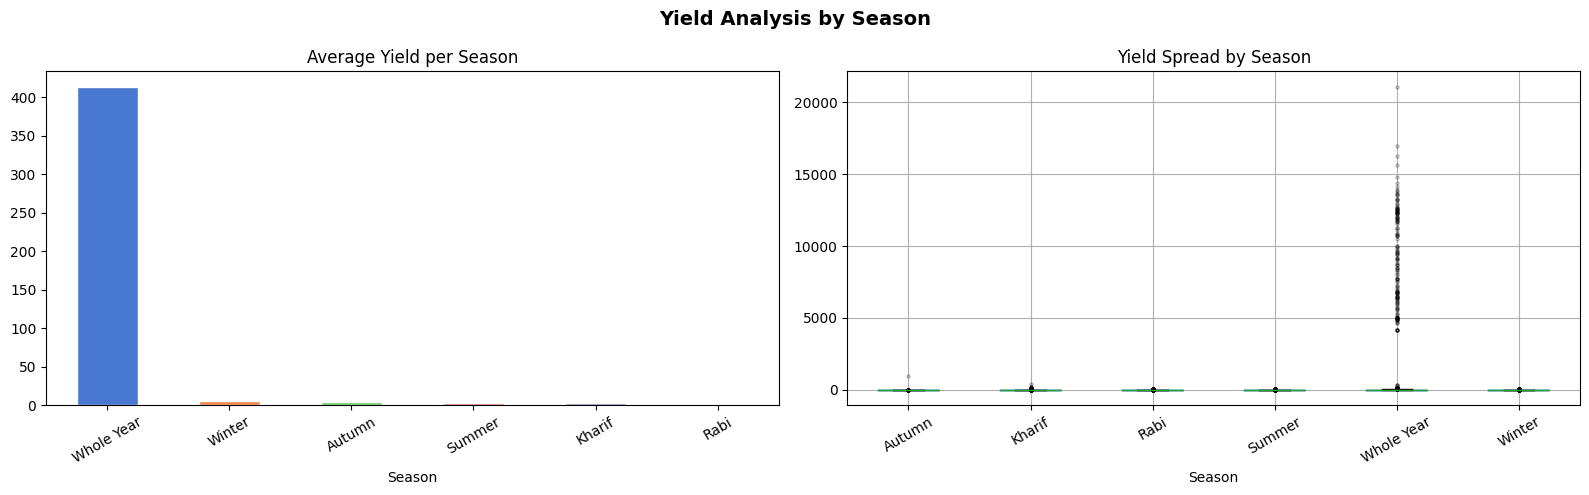

In [7]:
# 3.2 — Yield by Season
df_c = df.copy()
df_c['Season'] = df_c['Season'].str.strip()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Yield Analysis by Season', fontsize=14, fontweight='bold')

season_avg = df_c.groupby('Season')['Yield'].mean().sort_values(ascending=False)
season_avg.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(season_avg)), edgecolor='white')
axes[0].set_title('Average Yield per Season'); axes[0].tick_params(axis='x', rotation=30)

df_c.boxplot(column='Yield', by='Season', ax=axes[1],
             flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Yield Spread by Season'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Yield Analysis by Season', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

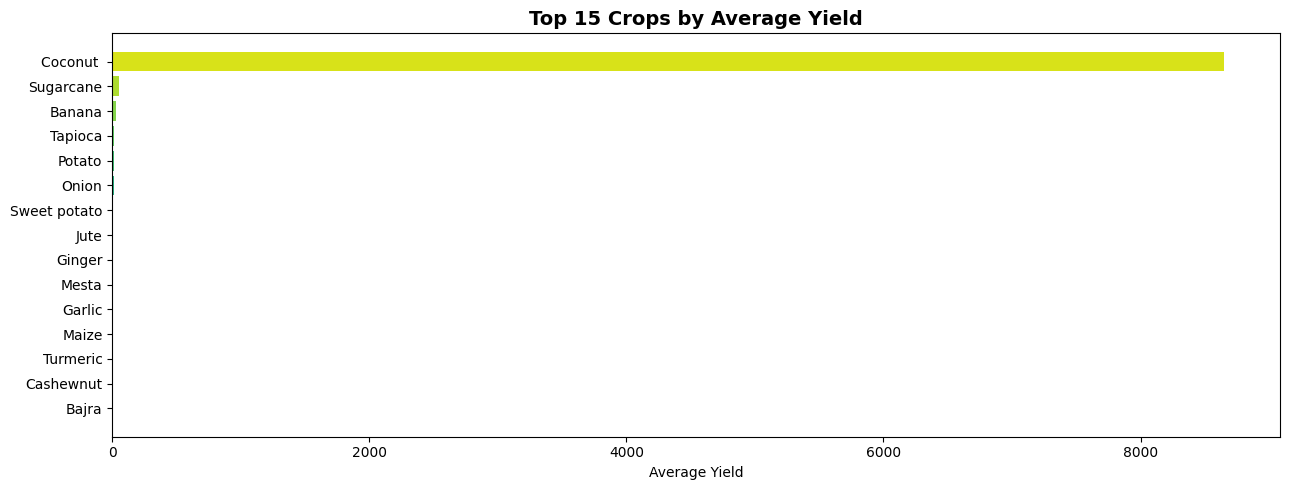

In [8]:
# 3.3 — Top 15 Crops by Average Yield
top_crops = df_c.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(13, 5))
plt.barh(top_crops.index[::-1], top_crops.values[::-1],
         color=sns.color_palette('viridis', 15))
plt.title('Top 15 Crops by Average Yield', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield')
plt.tight_layout()
plt.show()

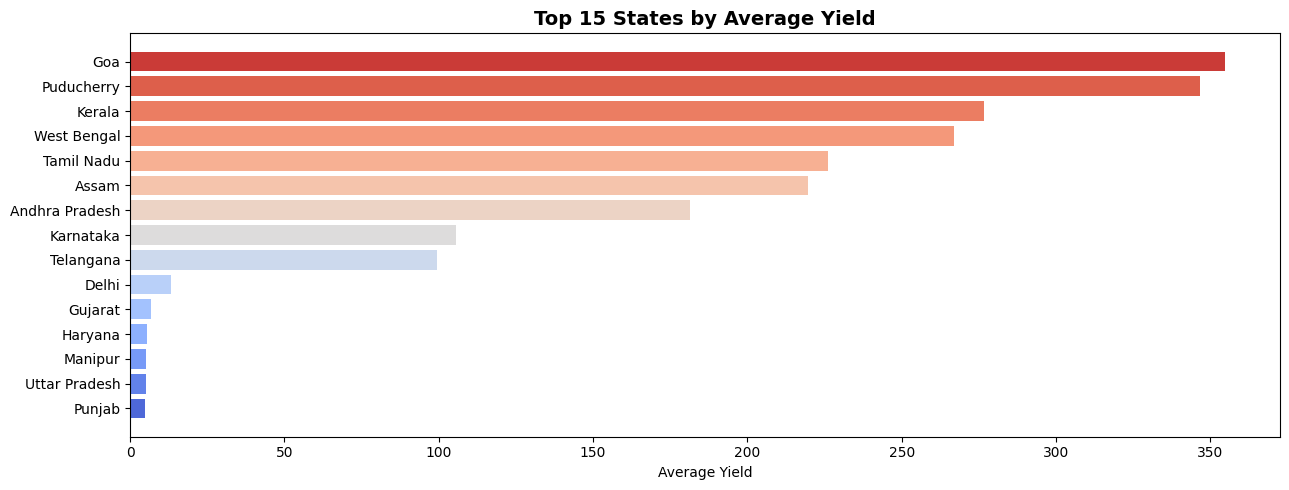

In [9]:
# 3.4 — Top 15 States by Average Yield
top_states = df_c.groupby('State')['Yield'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(13, 5))
plt.barh(top_states.index[::-1], top_states.values[::-1],
         color=sns.color_palette('coolwarm', 15))
plt.title('Top 15 States by Average Yield', fontsize=14, fontweight='bold')
plt.xlabel('Average Yield')
plt.tight_layout()
plt.show()

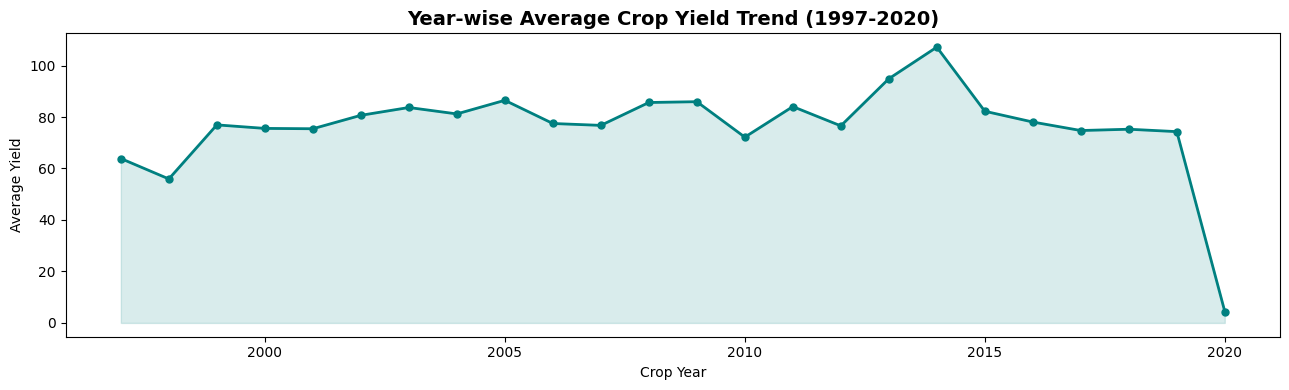

In [10]:
# 3.5 — Year-wise Yield Trend
yearly = df.groupby('Crop_Year')['Yield'].mean()

plt.figure(figsize=(13, 4))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2, color='teal', markersize=5)
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='teal')
plt.title('Year-wise Average Crop Yield Trend (1997-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Crop Year'); plt.ylabel('Average Yield')
plt.tight_layout()
plt.show()

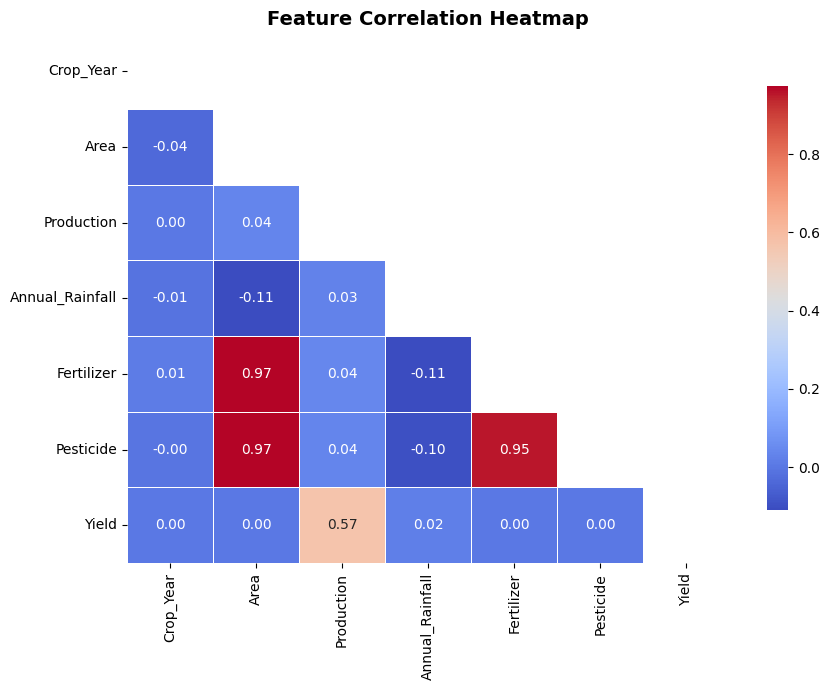

In [11]:
# 3.6 — Correlation Heatmap
num_cols = ['Crop_Year','Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 10}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

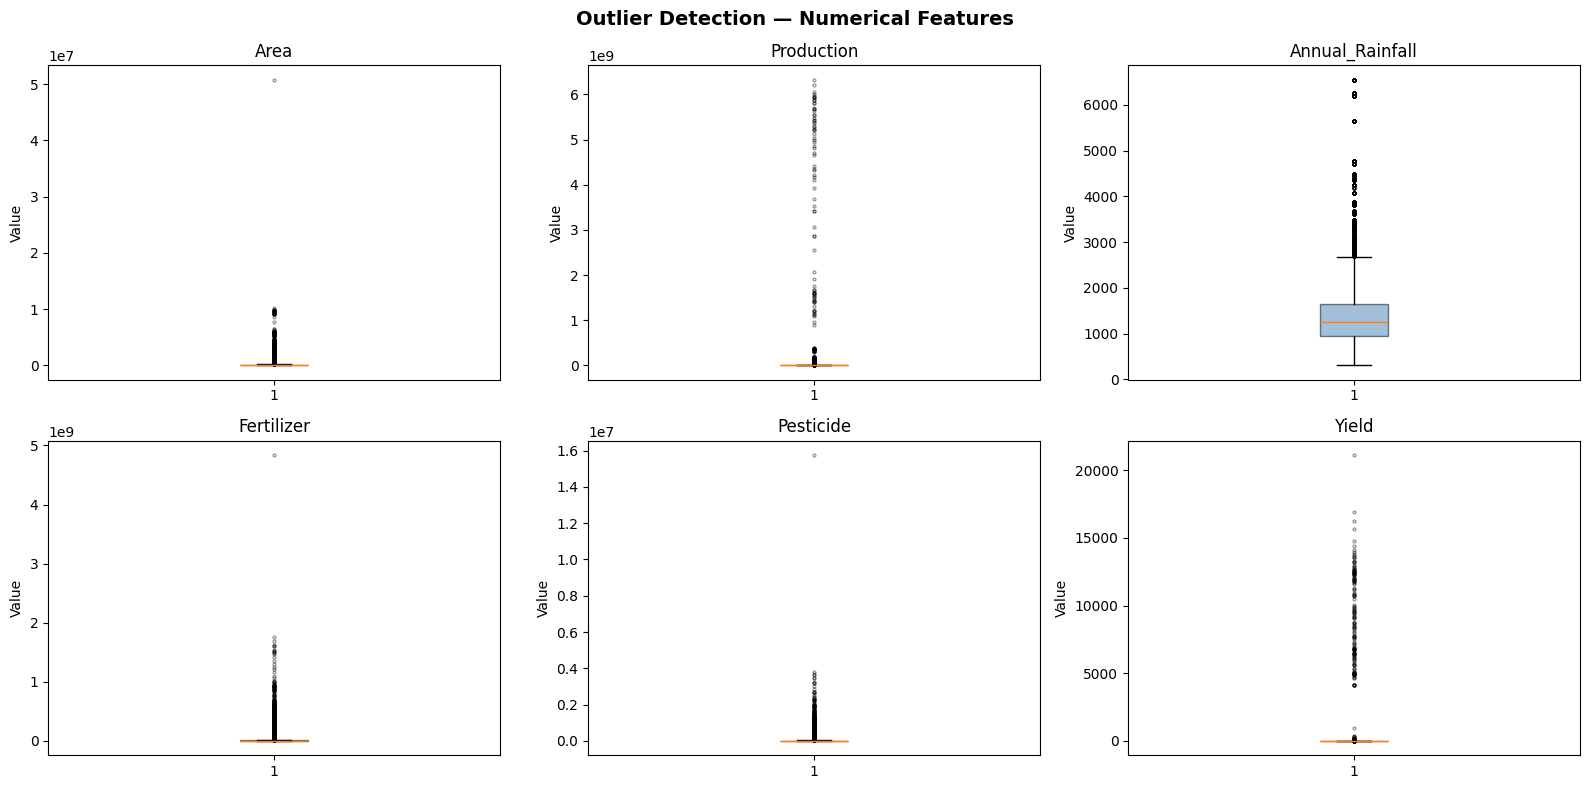

In [12]:
# 3.7 — Outlier Detection
num_features = ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Outlier Detection — Numerical Features', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_features):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               flierprops=dict(marker='o', markersize=2, alpha=0.4, color='red'))
    ax.set_title(col); ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

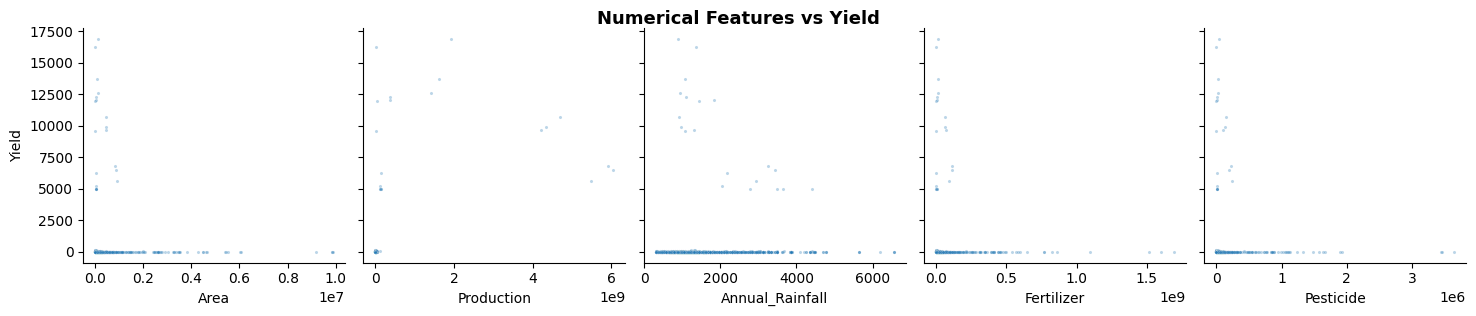

In [13]:
# 3.8 — Pairplot (sampled)
pair_cols = ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield']
sample = df[pair_cols].sample(n=2000, random_state=42)

g = sns.pairplot(sample, y_vars=['Yield'],
                 x_vars=['Area','Production','Annual_Rainfall','Fertilizer','Pesticide'],
                 plot_kws={'alpha':0.3,'s':5}, height=3)
g.fig.suptitle('Numerical Features vs Yield', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 4. Feature Engineering & Preprocessing

In [14]:
# 4.1 — Strip whitespace
df['Crop']   = df['Crop'].str.strip()
df['Season'] = df['Season'].str.strip()
df['State']  = df['State'].str.strip()
print('Cleaned string columns.')

Cleaned string columns.


In [15]:
# 4.2 — Log-transform the highly skewed target
df['Yield_log'] = np.log1p(df['Yield'])
print(f'Yield skewness     : {df["Yield"].skew():.3f}')
print(f'Log-Yield skewness : {df["Yield_log"].skew():.3f}')

Yield skewness     : 12.785
Log-Yield skewness : 3.661


In [16]:
# 4.3 — Label Encoding for categorical columns
le_crop   = LabelEncoder()
le_season = LabelEncoder()
le_state  = LabelEncoder()

df['Crop_enc']   = le_crop.fit_transform(df['Crop'])
df['Season_enc'] = le_season.fit_transform(df['Season'])
df['State_enc']  = le_state.fit_transform(df['State'])

# ✅ Create folders before saving



joblib.dump(le_crop,   'le_crop.pkl')
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_state,  'le_state.pkl')
print('Encoders saved.')

Encoders saved.


In [17]:
# 4.4 — Define feature matrix and target
FEATURES = ['Crop_enc','Crop_Year','Season_enc','State_enc',
            'Area','Production','Annual_Rainfall','Fertilizer','Pesticide']

X = df[FEATURES]
y = df['Yield_log']

print('X shape:', X.shape)
print('y shape:', y.shape)
X.head(3)

X shape: (19689, 9)
y shape: (19689,)


,Crop_enc,Crop_Year,Season_enc,State_enc,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
0,0,1997,4,2,73814.0,56708,2051.4,7024878.38,22882.34
1,1,1997,1,2,6637.0,4685,2051.4,631643.29,2057.47
2,8,1997,1,2,796.0,22,2051.4,75755.32,246.76


---
## 5. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Total   : {len(X):,}')
print(f'Train   : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test    : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')

Total   : 19,689
Train   : 15,751  (80.0%)
Test    : 3,938   (20.0%)


---
## 6. Feature Scaling

In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # transform test

joblib.dump(scaler, 'scaler.pkl')
print('StandardScaler fitted and saved.')

StandardScaler fitted and saved.


---
## 7. Model Training

In [20]:
# Helper — evaluate model and store results
results = {}

def evaluate(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    p_tr = model.predict(Xtr)
    p_te = model.predict(Xte)

    r2_tr   = r2_score(ytr, p_tr)
    r2_te   = r2_score(yte, p_te)
    rmse_tr = np.sqrt(mean_squared_error(np.expm1(ytr), np.expm1(p_tr)))
    rmse_te = np.sqrt(mean_squared_error(np.expm1(yte), np.expm1(p_te)))

    results[name] = {
        'Train R2':   round(r2_tr,   4),
        'Test R2':    round(r2_te,   4),
        'Train RMSE': round(rmse_tr, 4),
        'Test RMSE':  round(rmse_te, 4),
    }

    print(f'\n{name}')
    print(f'  Train R2={r2_tr:.4f}  |  Test R2={r2_te:.4f}')
    print(f'  Train RMSE={rmse_tr:.4f}  |  Test RMSE={rmse_te:.4f}')
    return model

In [21]:
# 7.1 — Linear Regression
lr = evaluate('Linear Regression', LinearRegression(),
              X_train_sc, y_train, X_test_sc, y_test)
joblib.dump(lr, 'linear_regression.pkl')


Linear Regression
  Train R2=0.2789  |  Test R2=0.2742
  Train RMSE=3576.3895  |  Test RMSE=4673.9079


['linear_regression.pkl']

In [22]:
# 7.2 — Decision Tree
dt = evaluate('Decision Tree',
              DecisionTreeRegressor(max_depth=10, min_samples_split=10,
                                    min_samples_leaf=5, random_state=42),
              X_train_sc, y_train, X_test_sc, y_test)
joblib.dump(dt, 'decision_tree.pkl')


Decision Tree
  Train R2=0.9550  |  Test R2=0.9413
  Train RMSE=193.7444  |  Test RMSE=316.4959


['decision_tree.pkl']

In [23]:
# 7.3 — Random Forest
rf = evaluate('Random Forest',
              RandomForestRegressor(n_estimators=150, max_depth=12,
                                    min_samples_leaf=4, n_jobs=-1, random_state=42),
              X_train_sc, y_train, X_test_sc, y_test)
joblib.dump(rf, 'random_forest.pkl')


Random Forest
  Train R2=0.9793  |  Test R2=0.9749
  Train RMSE=191.7355  |  Test RMSE=307.2962


['random_forest.pkl']

In [24]:
# 7.4 — XGBoost
xgb = evaluate('XGBoost',
               XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                            subsample=0.8, colsample_bytree=0.8,
                            n_jobs=-1, random_state=42, verbosity=0),
               X_train_sc, y_train, X_test_sc, y_test)
joblib.dump(xgb, 'xgboost.pkl')


XGBoost
  Train R2=0.9967  |  Test R2=0.9913
  Train RMSE=55.3757  |  Test RMSE=206.5227


['xgboost.pkl']

---
## 8. Model Comparison & Visualisation

In [25]:
# 8.1 — Summary Table
results_df = (pd.DataFrame(results).T
                .reset_index().rename(columns={'index':'Model'})
                .sort_values('Test R2', ascending=False)
                .reset_index(drop=True))

styled = (results_df.style
          .background_gradient(subset=['Train R2','Test R2'],     cmap='Greens')
          .background_gradient(subset=['Train RMSE','Test RMSE'], cmap='Reds_r')
          .set_caption('Model Performance Comparison')
          .format({'Train R2':'{:.4f}','Test R2':'{:.4f}',
                   'Train RMSE':'{:.2f}','Test RMSE':'{:.2f}'}))
styled

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,XGBoost,0.9967,0.9913,55.38,206.52
1,Random Forest,0.9793,0.9749,191.74,307.30
2,Decision Tree,0.9550,0.9413,193.74,316.50
3,Linear Regression,0.2789,0.2742,3576.39,4673.91


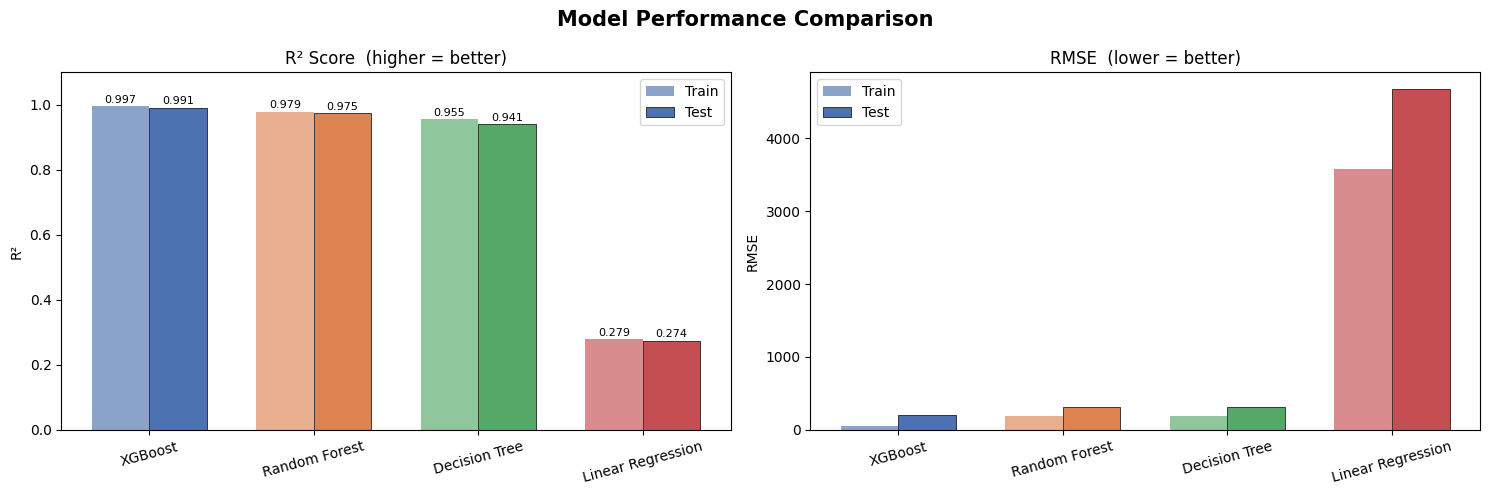

In [26]:
# 8.2 — Grouped Bar Chart: R2 & RMSE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

models = results_df['Model'].tolist()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
x, w  = np.arange(len(models)), 0.35

# R2
axes[0].bar(x - w/2, results_df['Train R2'], w, label='Train', color=colors, alpha=0.65)
axes[0].bar(x + w/2, results_df['Test R2'],  w, label='Test',  color=colors, alpha=1.0, edgecolor='black', lw=0.5)
axes[0].set_title('R² Score  (higher = better)')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylim(0, 1.1); axes[0].legend(); axes[0].set_ylabel('R²')
for i,(tr,te) in enumerate(zip(results_df['Train R2'], results_df['Test R2'])):
    axes[0].text(i-w/2, tr+0.01, f'{tr:.3f}', ha='center', fontsize=8)
    axes[0].text(i+w/2, te+0.01, f'{te:.3f}', ha='center', fontsize=8)

# RMSE
axes[1].bar(x - w/2, results_df['Train RMSE'], w, label='Train', color=colors, alpha=0.65)
axes[1].bar(x + w/2, results_df['Test RMSE'],  w, label='Test',  color=colors, alpha=1.0, edgecolor='black', lw=0.5)
axes[1].set_title('RMSE  (lower = better)')
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15)
axes[1].legend(); axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

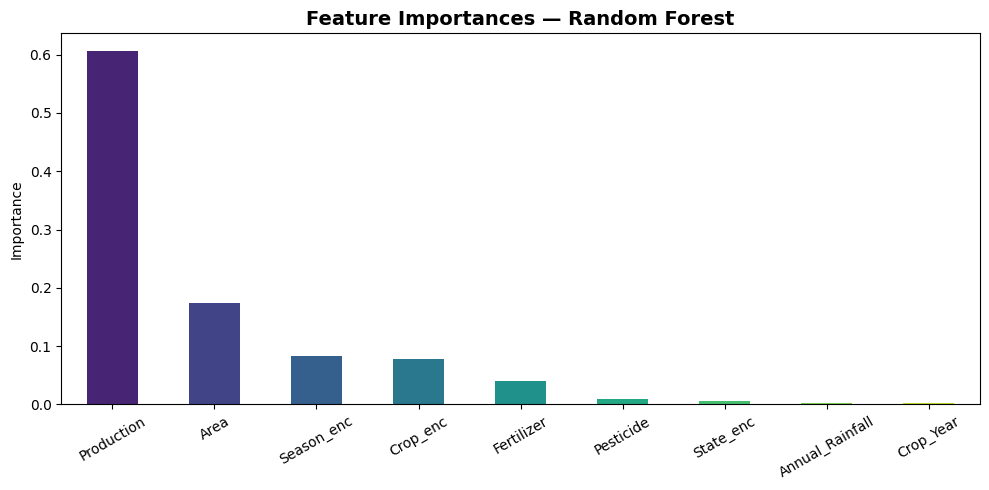

In [27]:
# 8.3 — Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color=sns.color_palette('viridis', len(feat_imp)))
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

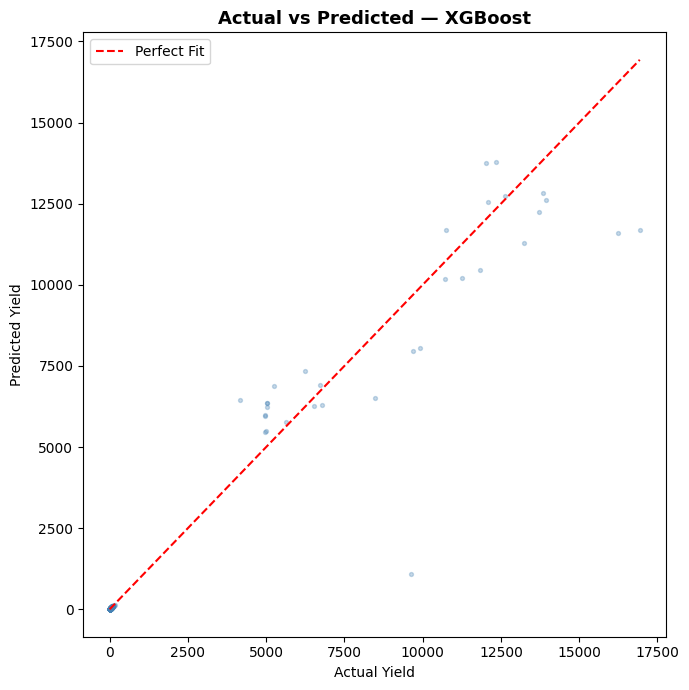

Best Model: XGBoost  |  Test R2 = 0.9913


In [28]:
# 8.4 — Actual vs Predicted (Best Model)
model_map = {'Linear Regression':lr, 'Decision Tree':dt,
             'Random Forest':rf, 'XGBoost':xgb}
best_name  = results_df.iloc[0]['Model']
best_model = model_map[best_name]

y_pred_orig = np.expm1(best_model.predict(X_test_sc))
y_true_orig = np.expm1(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_true_orig, y_pred_orig, alpha=0.3, s=8, color='steelblue')
lim = max(y_true_orig.max(), y_pred_orig.max())
plt.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect Fit')
plt.title(f'Actual vs Predicted — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Actual Yield'); plt.ylabel('Predicted Yield')
plt.legend(); plt.tight_layout()
plt.savefig('11_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Model: {best_name}  |  Test R2 = {results_df.iloc[0]["Test R2"]}')

---
## 9. Save Best Model

In [29]:
joblib.dump(best_model, 'best_model.pkl')

print(f'Best model saved: {best_name}')
print('\nAll saved artefacts:')
for f in sorted([f for f in os.listdir('.') if f.endswith('.pkl')]):
    print(f'  {f}')

Best model saved: XGBoost

All saved artefacts:
  best_model.pkl
  decision_tree.pkl
  le_crop.pkl
  le_season.pkl
  le_state.pkl
  linear_regression.pkl
  random_forest.pkl
  scaler.pkl
  xgboost.pkl
